In [59]:
import torch
torch_version = torch.__version__.split('+')[0]
scatter_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
sparse_src = f"https://pytorch-geometric.com/whl/torch-{torch_version}.html"
!pip install torch-scatter -f $scatter_src
!pip install torch-sparse -f $sparse_src
!pip install torch-geometric
!pip install pyg-lib
!pip install scikit-learn
!pip install -q git+https://github.com/snap-stanford/deepsnap.git

Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2.html
Looking in links: https://pytorch-geometric.com/whl/torch-2.2.2.html


ERROR: Could not find a version that satisfies the requirement pyg-lib (from versions: none)
ERROR: No matching distribution found for pyg-lib


  ERROR: Error [WinError 2] The system cannot find the file specified while executing command git clone -q https://github.com/snap-stanford/deepsnap.git 'C:\Users\SRMAPCSELAB2022-346\AppData\Local\Temp\pip-req-build-_5wis0nj'
ERROR: Cannot find command 'git' - do you have 'git' installed and in your PATH?


In [60]:
import torch
print(torch.__version__)

2.2.2+cpu


In [61]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import copy
from sklearn.model_selection import train_test_split
from torch_geometric.data import HeteroData
from torch_geometric.utils import dropout_edge, negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import trange
import time
import matplotlib.pyplot as plt
import requests
import zipfile
import io
import os
import pandas as pd

In [62]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_scatter import scatter_add
import random
import numpy as np

seed = 42

random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

if torch.cuda.is_available():
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"Random seed set to {seed}")

class SGL(nn.Module):

    def __init__(
            self,
            num_users,
            num_items,
            hidden_size=256,
            num_layers=3,
            edge_dropout=0.1,
            temperature=0.2,
            ssl_weight=0.1,
            reg_weight=1e-5):

        super().__init__()

        self.num_users = num_users
        self.num_items = num_items

        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.temperature = temperature
        self.ssl_weight = ssl_weight
        self.reg_weight = reg_weight

        self.edge_dropout_prob = edge_dropout

        ####################################################
        # Embeddings
        ####################################################

        self.user_embeddings = nn.Embedding(
            num_users,
            hidden_size
        )

        self.item_embeddings = nn.Embedding(
            num_items,
            hidden_size
        )

        nn.init.xavier_uniform_(
            self.user_embeddings.weight
        )

        nn.init.xavier_uniform_(
            self.item_embeddings.weight
        )

    ########################################################
    # Standard Edge Dropout
    ########################################################

    def edge_dropout(
            self,
            edge_index,
            p=None):

        if p is None:
            p = self.edge_dropout_prob

        if (not self.training) or p == 0:
            return edge_index

        mask = (
            torch.rand(
                edge_index.size(1),
                device=edge_index.device
            ) > p
        )

        return edge_index[:, mask]

    ########################################################
    # Generate Two Views
    ########################################################

    def generate_views(
            self,
            edge_index):

        view1 = self.edge_dropout(
            edge_index
        )

        view2 = self.edge_dropout(
            edge_index
        )

        return view1, view2

    ########################################################
    # LightGCN Propagation
    ########################################################

    def propagate(
            self,
            user_emb,
            item_emb,
            edge_index):

        x = torch.cat(
            [user_emb, item_emb],
            dim=0
        )

        embeddings = [x]

        src = edge_index[0]
        dst = edge_index[1] + self.num_users
        
        edge_index = torch.cat([
            torch.stack([src, dst], dim=0),
            torch.stack([dst, src], dim=0)
        ], dim=1)

        src = edge_index[0]
        dst = edge_index[1]
        
        num_nodes = x.size(0)
        
        edge_weight = torch.ones(
            edge_index.size(1),
            device=edge_index.device
        )

           
        deg = scatter_add(
             edge_weight,
             src,
             dim=0,
             dim_size=num_nodes
        )

        deg = deg.clamp(min=1)

        for _ in range(self.num_layers):

            norm = (
                deg[src].pow(-0.5)
                *
                deg[dst].pow(-0.5)
            )

            x = scatter_add(
                x[src] * norm.unsqueeze(-1),
                dst,
                dim=0,
                dim_size=num_nodes
            )

            embeddings.append(x)

        final_embedding = (
            torch.stack(
                embeddings,
                dim=0
            ).mean(dim=0)
        )

        user_embedding = (
            final_embedding[
                :self.num_users
            ]
        )

        item_embedding = (
            final_embedding[
                self.num_users:
            ]
        )

        return (
            user_embedding,
            item_embedding
        )

    ########################################################
    # Forward
    ########################################################

    def forward(
            self,
            edge_index,
            return_views=False):

        user_emb = (
            self.user_embeddings.weight
        )

        item_emb = (
            self.item_embeddings.weight
        )

        if self.training and return_views:

            view1, view2 = (
                self.generate_views(
                    edge_index
                )
            )

            emb1 = self.propagate(
                user_emb,
                item_emb,
                view1
            )

            emb2 = self.propagate(
                user_emb,
                item_emb,
                view2
            )

            return emb1, emb2

        return self.propagate(
            user_emb,
            item_emb,
            edge_index
        )

    ########################################################
    # Prediction
    ########################################################

    def predict(
            self,
            user_emb,
            item_emb,
            user_ids,
            item_ids):

        u = user_emb[user_ids]

        i = item_emb[item_ids]

        return torch.sum(
            u * i,
            dim=-1
        )

    ########################################################
    # InfoNCE Loss
    ########################################################

    def contrastive_loss(self,user_emb1,user_emb2):

        z1 = F.normalize(user_emb1,dim=1)

        z2 = F.normalize(user_emb2,dim=1)

       
        logits_12 = torch.mm(z1, z2.t()) / self.temperature
        logits_21 = torch.mm(z2, z1.t()) / self.temperature 
                
        labels = torch.arange(z1.size(0),device=z1.device)

        loss1 = F.cross_entropy(logits_12,labels)

        loss2 = F.cross_entropy(logits_21,labels)

        ssl_loss = (loss1 + loss2) / 2
        

        return ssl_loss

    ########################################################
    # BPR Loss
    ########################################################

    def bpr_loss(
            self,
            user_emb,
            item_emb,
            pos_edge_index,
            neg_edge_index):

        pos_scores = self.predict(
            user_emb,
            item_emb,
            pos_edge_index[0],
            pos_edge_index[1]
        )

        neg_scores = self.predict(
            user_emb,
            item_emb,
            neg_edge_index[0],
            neg_edge_index[1]
        )

        bpr = -torch.log(
            torch.sigmoid(
                pos_scores -
                neg_scores
            ) + 1e-12
        ).mean()

        reg_loss = (
            self.user_embeddings.weight
            .norm(2).pow(2)
            +
            self.item_embeddings.weight
            .norm(2).pow(2)
        )

        reg_loss = (
            self.reg_weight *
            reg_loss
        )

        return bpr + reg_loss

    ########################################################
    # Total Loss
    ########################################################

    def total_loss(
            self,
            pos_edge_index,
            neg_edge_index,
            edge_index):
        (
            (user_emb1, item_emb1),
            (user_emb2, item_emb2)
        ) = self.forward(
            edge_index,
            return_views=True
        )

        bpr = self.bpr_loss(
            user_emb1,
            item_emb1,
            pos_edge_index,
            neg_edge_index
        )

        user_ssl = self.contrastive_loss(
            user_emb1,
            user_emb2
        )

        item_ssl = self.contrastive_loss(
            item_emb1,
            item_emb2
        )

        ssl = (user_ssl + item_ssl) / 2

        total = (
            bpr +
            self.ssl_weight * ssl
        )

        return total, bpr, ssl

Random seed set to 42


In [63]:
def prepare_sgl_data(data, val_ratio=0.1, test_ratio=0.1):
    """Prepare data for SGL training"""
    edge_index = data['user', 'rates', 'movie'].edge_index
    
    num_edges = edge_index.size(1)
    perm = torch.randperm(num_edges)
    
    num_val = int(num_edges * val_ratio)
    num_test = int(num_edges * test_ratio)
    num_train = num_edges - num_val - num_test
    
    train_idx = perm[:num_train]
    val_idx = perm[num_train:num_train + num_val]
    test_idx = perm[num_train + num_val:]
    
    train_pos_edge_index = edge_index[:, train_idx]
    val_pos_edge_index = edge_index[:, val_idx]
    test_pos_edge_index = edge_index[:, test_idx]
    
    num_users = data['user'].num_nodes
    num_items = data['movie'].num_nodes
    
    positive_set = set(
    map(tuple, edge_index.t().cpu().numpy())
    )
    
    def sample_negatives(num_samples):

        neg_edges = []

        while len(neg_edges) < num_samples:

            user = torch.randint(
                0,
                num_users,
                (1,)
            ).item()

            item = torch.randint(
                0,
                num_items,
                (1,)
            ).item()

            if (user, item) not in positive_set:

                neg_edges.append(
                    [user, item]
                )

        return torch.tensor(
            neg_edges,
            dtype=torch.long
        ).t()
    
    train_neg = sample_negatives(train_pos_edge_index.size(1))
    val_neg = sample_negatives(val_pos_edge_index.size(1))
    test_neg = sample_negatives(test_pos_edge_index.size(1))
    
    data.train_pos_edge_index = train_pos_edge_index
    data.train_neg_edge_index = train_neg
    data.val_edge_index = torch.cat([val_pos_edge_index, val_neg], dim=1)
    data.val_edge_label = torch.cat([torch.ones(val_pos_edge_index.size(1)), torch.zeros(val_neg.size(1))])
    data.test_edge_index = torch.cat([test_pos_edge_index, test_neg], dim=1)
    data.test_edge_label = torch.cat([torch.ones(test_pos_edge_index.size(1)), torch.zeros(test_neg.size(1))])
    
    return data


def train_sgl_with_data(data, config):
    """Train SGL model on MovieLens data"""
    device = config.get('device', torch.device('cuda' if torch.cuda.is_available() else 'cpu'))
    
    data = prepare_sgl_data(data)
    
    data.train_pos_edge_index = data.train_pos_edge_index.to(device)
    data.train_neg_edge_index = data.train_neg_edge_index.to(device)
    data.val_edge_index = data.val_edge_index.to(device)
    data.val_edge_label = data.val_edge_label.to(device)
    data.test_edge_index = data.test_edge_index.to(device)
    data.test_edge_label = data.test_edge_label.to(device)
    
    model = SGL(
        num_users=data['user'].num_nodes,
        num_items=data['movie'].num_nodes,
        hidden_size=config.get('hidden_size', 256),
        num_layers=config.get('num_layers', 3),
        edge_dropout=config.get('edge_dropout', 0.1),
        temperature=config.get('temperature', 0.2),
        ssl_weight=config.get('ssl_weight', 0.1),
        reg_weight=config.get('reg_weight', 1e-5)
    ).to(device)
    
    # Create optimizer and trainer function
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=config.get('learning_rate', 1e-4),
        weight_decay=config.get('weight_decay', 0)
    )
    
    num_epochs = config.get('epochs', 200)
    
    
    losses = []
    val_aucs = []
    
    
    print("Training SGL Model...")
    for epoch in trange(num_epochs, desc="SGL Training"):
        model.train()
        optimizer.zero_grad()
        
        # Forward pass with views
        (user_emb1, item_emb1), (user_emb2, item_emb2) = model(
            data.train_pos_edge_index,
            return_views=True
        )
        
        # Calculate losses
        total_loss, bpr_loss, ssl_loss = model.total_loss(
            data.train_pos_edge_index,
            data.train_neg_edge_index,
            data.train_pos_edge_index
        )
        
        total_loss.backward()
        optimizer.step()
        
        losses.append({
            'total_loss': total_loss.item(),
            'bpr_loss': bpr_loss.item() if isinstance(bpr_loss, torch.Tensor) else bpr_loss,
            'ssl_loss': ssl_loss.item() if isinstance(ssl_loss, torch.Tensor) else ssl_loss
        })
        
        if epoch % 5 == 0:
            model.eval()
            with torch.no_grad():
                user_emb, item_emb = model(data.train_pos_edge_index)
                
                # Validation prediction
                val_pred = model.predict(
                    user_emb,
                    item_emb,
                    data.val_edge_index[0],
                    data.val_edge_index[1]
                )
                val_pred = torch.sigmoid(val_pred)
                
                val_auc = roc_auc_score(
                    data.val_edge_label.cpu().numpy(),
                    val_pred.cpu().numpy()
                )
                val_aucs.append(val_auc)
                
                
        
    model.eval()
    with torch.no_grad():
        # Test prediction
        user_emb, item_emb = model(data.train_pos_edge_index)
        
        test_pred = model.predict(
            user_emb,
            item_emb,
            data.test_edge_index[0],
            data.test_edge_index[1]
        )
        test_pred = torch.sigmoid(test_pred)
        
        test_auc = roc_auc_score(
            data.test_edge_label.cpu().numpy(),
            test_pred.cpu().numpy()
        )
        
        test_ap = average_precision_score(
            data.test_edge_label.cpu().numpy(),
            test_pred.cpu().numpy()
        )
        
        test_metrics = {'AUC': test_auc, 'AP': test_ap}
        
        # Calculate recommendation metrics
        rec_metrics = evaluate_recommendation_metrics(
            model,
            data.train_pos_edge_index,
            data.test_edge_index,
            data.test_edge_label,
            k_list=[5, 10, 20]
        )
    
    return {
        'model': model,
        'losses': losses,
        'val_aucs': val_aucs,
        'test_metrics': test_metrics,
        'rec_metrics': rec_metrics
        
    }

## Training and Testing

In [64]:
import torch.optim as optim
import time
import numpy as np
import matplotlib.pyplot as plt
import os
import pandas as pd
import torch
import numpy as np
from torch_geometric.data import HeteroData
import requests
import zipfile
import io
from torch_geometric.utils import negative_sampling
from sklearn.metrics import roc_auc_score, average_precision_score
from tqdm import trange
import torch
import torch.nn.functional as F
from torch_geometric.utils import negative_sampling
from sklearn.model_selection import train_test_split
import numpy as np

def download_and_extract_movielens():
    """Download MovieLens 100K dataset and extract it"""

    print("Downloading MovieLens 100K dataset...")

    url = "https://files.grouplens.org/datasets/movielens/ml-100k.zip"
    response = requests.get(url, timeout=60)

    if response.status_code != 200:
        raise Exception(f"Failed to download dataset: HTTP {response.status_code}")

    extract_path = 'movielens'
    if not os.path.exists(extract_path):
        os.makedirs(extract_path)

    with zipfile.ZipFile(io.BytesIO(response.content)) as zip_ref:
        zip_ref.extractall(extract_path)

    print("Dataset downloaded and extracted successfully!")

    extracted_folder = os.path.join(extract_path, 'ml-100k')

    if os.path.exists(extracted_folder):
        print(f"Files extracted to: {extracted_folder}")
        return extracted_folder
    else:
        return extract_path

def encode_user_features(users_df):
    """Encode user features for MovieLens 100K"""

    print("User data info:")
    print(f"  Age range: {users_df['Age'].min()} - {users_df['Age'].max()}")

    # Gender
    gender = torch.tensor(
        [0 if g == 'M' else 1 for g in users_df['Gender']],
        dtype=torch.float
    ).unsqueeze(1)

    # Age (Min-Max normalization)
    age = torch.tensor(
        users_df['Age'].values,
        dtype=torch.float
    ).unsqueeze(1)

    age = (age - age.min()) / (age.max() - age.min())

    # Occupation
    occupations = users_df['Occupation'].astype('category')

    occupation_codes = torch.tensor(
        occupations.cat.codes.values,
        dtype=torch.long
    )

    num_occupations = len(occupations.cat.categories)

    occupation_onehot = F.one_hot(
        occupation_codes,
        num_classes=num_occupations
    ).float()

    # Combine features
    user_features = torch.cat(
        [
            gender,
            age,
            occupation_onehot
        ],
        dim=1
    )

    print(f"  Number of occupations: {num_occupations}")
    print(f"  User feature dimension: {user_features.shape[1]}")

    return user_features

def encode_movie_features(movies_df):
    """Encode MovieLens 100K movie genres"""

    genre_columns = [
        'unknown',
        'Action',
        'Adventure',
        'Animation',
        "Children's",
        'Comedy',
        'Crime',
        'Documentary',
        'Drama',
        'Fantasy',
        'Film-Noir',
        'Horror',
        'Musical',
        'Mystery',
        'Romance',
        'Sci-Fi',
        'Thriller',
        'War',
        'Western'
    ]

    print("Movie data info:")
    print(f"  Total genres: {len(genre_columns)}")

    movie_features = torch.tensor(
        movies_df[genre_columns].values,
        dtype=torch.float
    )

    print(f"  Movie feature dimension: {movie_features.shape[1]}")

    return movie_features

def load_movielens_heterogeneous(data_path, use_features=True, use_temporal=True):
    """Load MovieLens dataset with real features and timestamps"""
    
    print(f"Loading MovieLens dataset from: {data_path}")
    
    print("\nAvailable files in directory:")
    try:
        for f in os.listdir(data_path):
            print(f"  - {f}")
    except:
        print("  Could not list directory contents")
    
    # Load files
    try:
        users_df = pd.read_csv(
            os.path.join(data_path, 'u.user'),
            sep='|',
            names=['UserID','Age','Gender','Occupation','Zip'],
            encoding='latin-1'
        )
        print(f"✓ Loaded u.user: {len(users_df)} records")
    except Exception as e:
        print(f"✗ u.user not found or error: {e}")
        raise

    try:
        movie_cols = [
            'MovieID','Title','ReleaseDate','VideoReleaseDate',
            'IMDbURL',
            'unknown','Action','Adventure','Animation',
            "Children's",'Comedy','Crime','Documentary',
            'Drama','Fantasy','Film-Noir','Horror',
            'Musical','Mystery','Romance','Sci-Fi',
            'Thriller','War','Western'
        ]

        
        movies_df = pd.read_csv(
            os.path.join(data_path,'u.item'),
            sep='|',
            names=movie_cols,
            encoding='latin-1',
            engine='python'
        )
        print(f"✓ Loaded u.item: {len(movies_df)} records")
    except Exception as e:
        print(f"✗ u.item not found or error: {e}")
        raise

    try:
        ratings_df = pd.read_csv(
            os.path.join(data_path,'u.data'),
            sep='\t',
            names=['UserID','MovieID','Rating','Timestamp'],
            engine='python'
        )
        print(f"✓ Loaded u.data: {len(ratings_df)} records")
    except Exception as e:
        print(f"✗ u.data not found or error: {e}")
        raise

    # Create HeteroData
    data = HeteroData()

    # Unique users & movies
    all_users = set(users_df['UserID']).union(set(ratings_df['UserID']))
    all_movies = set(movies_df['MovieID']).union(set(ratings_df['MovieID']))
    
    num_users = len(all_users)
    num_movies = len(all_movies)

    user_id_to_idx = {uid: i for i, uid in enumerate(sorted(all_users))}
    movie_id_to_idx = {mid: i for i, mid in enumerate(sorted(all_movies))}

    print(f"\nStatistics - Users: {num_users}, Movies: {num_movies}")

    # Encode features
    user_feat_dim = 0
    movie_feat_dim = 0
    
    if use_features:
        # Sort dataframes consistently
        users_df_sorted = users_df.sort_values('UserID').reset_index(drop=True)
        
        # Verify alignment
        expected_users = sorted(all_users)
        actual_users = users_df_sorted['UserID'].tolist()
        
        if expected_users != actual_users:
            print(f"Warning: User ID mismatch! Reindexing...")
            user_id_to_df_idx = {uid: i for i, uid in enumerate(users_df_sorted['UserID'])}
            reorder_indices = [user_id_to_df_idx[uid] for uid in expected_users]
            users_df_sorted = users_df_sorted.iloc[reorder_indices].reset_index(drop=True)
        
        user_features = encode_user_features(users_df_sorted)
        user_feat_dim = user_features.shape[1]
        
        movies_df_sorted = movies_df.sort_values('MovieID').reset_index(drop=True)
        
        # Verify alignment
        expected_movies = sorted(all_movies)
        actual_movies = movies_df_sorted['MovieID'].tolist()
        
        if expected_movies != actual_movies:
            print(f"Warning: Movie ID mismatch! Reindexing...")
            movie_id_to_df_idx = {mid: i for i, mid in enumerate(movies_df_sorted['MovieID'])}
            reorder_indices = [movie_id_to_df_idx[mid] for mid in expected_movies]
            movies_df_sorted = movies_df_sorted.iloc[reorder_indices].reset_index(drop=True)
        
        movie_features = encode_movie_features(movies_df_sorted)
        movie_feat_dim = movie_features.shape[1]
        
        print(f"\nFeature dimensions:")
        print(f"  User features: {user_feat_dim} dims")
        print(f"  Movie features: {movie_feat_dim} dims")
        
        data['user'].x = user_features
        data['movie'].x = movie_features
    

    data['user'].num_nodes = num_users
    data['movie'].num_nodes = num_movies

    # ============================
    # Edges: User → Movie (ratings) - UPDATED VERSION
    # ============================
    edge_index = []
    edge_weight = []
    timestamps = []

    valid_edges = 0
    skipped_users = set()
    skipped_movies = set()

    for _, row in ratings_df.iterrows():
        u = row['UserID']
        m = row['MovieID']

        if u in user_id_to_idx and m in movie_id_to_idx:
            edge_index.append([user_id_to_idx[u], movie_id_to_idx[m]])
            edge_weight.append(float(row['Rating']))
            if use_temporal:
                timestamps.append(float(row['Timestamp']))
            valid_edges += 1
        else:
            if u not in user_id_to_idx:
                skipped_users.add(u)
            if m not in movie_id_to_idx:
                skipped_movies.add(m)

    print(f"User-rates-movie relations: {valid_edges}")
    
    if skipped_users:
        print(f"  Skipped {len(skipped_users)} users not in user list")
    if skipped_movies:
        print(f"  Skipped {len(skipped_movies)} movies not in movie list")

    if edge_index:
        edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
        edge_weight = torch.tensor(edge_weight, dtype=torch.float)
        
        # Process timestamps if using temporal features
        timestamps_tensor = None
        if use_temporal and timestamps:
            # Normalize timestamps to [0, 1] range
            timestamps_tensor = torch.tensor(timestamps, dtype=torch.float)
            if timestamps_tensor.max() > timestamps_tensor.min():
                timestamps_tensor = (timestamps_tensor - timestamps_tensor.min()) / (timestamps_tensor.max() - timestamps_tensor.min())
            else:
                timestamps_tensor = torch.zeros_like(timestamps_tensor)

        data['user', 'rates', 'movie'].edge_index = edge_index
        data['user', 'rates', 'movie'].weight = edge_weight
        
        data['movie', 'rev_rates', 'user'].edge_index = edge_index.flip(0)
        data['movie', 'rev_rates', 'user'].weight = edge_weight
        
        # Only assign timestamp if we actually have temporal data
        if use_temporal and timestamps_tensor is not None:
            data['user', 'rates', 'movie'].timestamp = timestamps_tensor
            data['movie', 'rev_rates', 'user'].timestamp = timestamps_tensor

        data['user', 'rates', 'movie'].original_edge_index = edge_index.clone()

    print(f"\nFINAL STATISTICS:")
    print(f"  Users: {data['user'].num_nodes}")
    print(f"  Movies: {data['movie'].num_nodes}")
    print(f"  User→Movie edges: {valid_edges}")
    print(f"  User feature dimension: {user_feat_dim}")
    print(f"  Movie feature dimension: {movie_feat_dim}")
    if use_temporal:
        print(f"  Temporal information: enabled")

    return data, user_feat_dim, movie_feat_dim


def train_link_prediction_model(data, model, configuration):
    optimizer = optim.Adam(
        model.parameters(),
        lr=configuration.learning_rate,
        weight_decay=configuration.weight_decay
    )

    scheduler = optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=configuration.epochs,
        eta_min=1e-6
    )

    losses = []
    val_aucs = []

    best_val_auc = 0.0
    best_model_state = None

    num_epochs = configuration.epochs

    for epoch in trange(num_epochs):

        model.train()
        optimizer.zero_grad()

        node_features = {
            node_type: data[node_type].x
            for node_type in data.node_types
        }

        edge_indices = {
            edge_type: data[edge_type].edge_index
            for edge_type in data.edge_types
        }

        edge_timestamps = {}

        for edge_type in data.edge_types:
            if 'timestamp' in data[edge_type]:
                edge_timestamps[edge_type] = data[edge_type].timestamp

        z, importance = model(
            node_features,
            edge_indices,
            edge_timestamps
        )

        user_emb = z['user']
        movie_emb = z['movie']

        pos_edge_index = data.train_pos_edge_index
        num_pos = pos_edge_index.size(1)

        neg_edge_index = negative_sampling(
            edge_index=data['user', 'rates', 'movie'].edge_index,
            num_nodes=(
                data['user'].num_nodes,
                data['movie'].num_nodes
            ),
            num_neg_samples=num_pos
        )

        pos_pred = model.decode(
            user_emb,
            movie_emb,
            pos_edge_index
        )

        neg_pred = model.decode(
            user_emb,
            movie_emb,
            neg_edge_index
        )

        pos_loss = -torch.log(
            torch.sigmoid(pos_pred) + 1e-15
        ).mean()

        neg_loss = -torch.log(
            1 - torch.sigmoid(neg_pred) + 1e-15
        ).mean()

        loss = pos_loss + neg_loss

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        optimizer.step()
        scheduler.step()

        losses.append(loss.item())

        if epoch % 5 == 0:

            model.eval()

            with torch.no_grad():

                z, importance = model(
                    node_features,
                    edge_indices,
                    edge_timestamps
                )

                user_emb = z['user']
                movie_emb = z['movie']

                val_pred = model.decode(
                    user_emb,
                    movie_emb,
                    data.val_edge_index
                )

                val_pred = torch.sigmoid(val_pred)

                val_auc = roc_auc_score(
                    data.val_edge_label.cpu().numpy(),
                    val_pred.cpu().numpy()
                )

                val_aucs.append(val_auc)

                if val_auc > best_val_auc:

                    best_val_auc = val_auc

                    best_model_state = {
                        k: v.cpu().clone()
                        for k, v in model.state_dict().items()
                    }

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()

    with torch.no_grad():

        node_features = {
            node_type: data[node_type].x
            for node_type in data.node_types
        }

        edge_indices = {
            edge_type: data[edge_type].edge_index
            for edge_type in data.edge_types
        }

        edge_timestamps = {}

        for edge_type in data.edge_types:
            if 'timestamp' in data[edge_type]:
                edge_timestamps[edge_type] = data[edge_type].timestamp

        z, importance = model(
            node_features,
            edge_indices,
            edge_timestamps
        )

        user_emb = z['user']
        movie_emb = z['movie']

        test_pred = model.decode(
            user_emb,
            movie_emb,
            data.test_edge_index
        )

        test_pred = torch.sigmoid(test_pred)

        test_auc = roc_auc_score(
            data.test_edge_label.cpu().numpy(),
            test_pred.cpu().numpy()
        )

        test_ap = average_precision_score(
            data.test_edge_label.cpu().numpy(),
            test_pred.cpu().numpy()
        )

    test_metrics = {
        'auc': test_auc,
        'ap': test_ap
    }

    return (
        val_aucs,
        losses,
        model,
        test_metrics
    )


def evaluate_recommendation_clean(
    model,
    data,
    k_list=[5, 10, 20]
):
    """
    Fast recommendation evaluation
    Computes:
    HR@K
    NDCG@K
    MRR
    """

    model.eval()

    HR = {
        k: []
        for k in k_list
    }

    NDCG = {
        k: []
        for k in k_list
    }

    MRR = []

    with torch.no_grad():

        # =====================================
        # Generate embeddings
        # =====================================
        node_features = {
            node_type: data[node_type].x
            for node_type in data.node_types
        }

        edge_indices = {
            edge_type: data[edge_type].edge_index
            for edge_type in data.edge_types
        }

        edge_timestamps = {}

        for edge_type in data.edge_types:

            if 'timestamp' in data[edge_type]:

                edge_timestamps[edge_type] = (
                    data[edge_type].timestamp
                )

        z, _ = model(
            node_features,
            edge_indices,
            edge_timestamps
        )

        user_emb = z['user']
        movie_emb = z['movie']

        # =====================================
        # Positive Test Edges
        # =====================================
        pos_edges = data.test_edge_index[
            :,
            data.test_edge_label == 1
        ]

        if pos_edges.size(1) == 0:

            print(
                "Warning: No positive test edges."
            )

            results = {}

            for k in k_list:

                results[f'HR@{k}'] = 0
                results[f'NDCG@{k}'] = 0

            results['MRR'] = 0

            return results

        # =====================================
        # Evaluate only subset
        # =====================================
        max_eval_edges = 5000

        if pos_edges.size(1) > max_eval_edges:

            eval_idx = np.random.choice(
                pos_edges.size(1),
                max_eval_edges,
                replace=False
            )

            pos_edges = pos_edges[
                :,
                eval_idx
            ]

        # =====================================
        # Build user history lookup
        # =====================================
        user_positive_items = {}

        edge_sets = [
            (
                data.train_edge_index,
                data.train_edge_label
            ),
            (
                data.val_edge_index,
                data.val_edge_label
            ),
            (
                data.test_edge_index,
                data.test_edge_label
            )
           ]
            

        for edge_index, edge_label in edge_sets:

            positive_edges = edge_index[
                :,
                edge_label == 1
            ]

            for i in range(
                positive_edges.size(1)
            ):

                u = positive_edges[
                    0,
                    i
                ].item()

                m = positive_edges[
                    1,
                    i
                ].item()

                if u not in user_positive_items:

                    user_positive_items[u] = set()

                user_positive_items[u].add(m)

        # =====================================
        # Movie Set
        # =====================================
        all_movies = set(
            range(
                data['movie'].num_nodes
            )
        )

        # =====================================
        # Evaluate
        # =====================================
        for edge in pos_edges.t():

            user = edge[0].item()
            pos_movie = edge[1].item()

            user_seen = (
                user_positive_items.get(
                    user,
                    set()
                )
            )

            candidate_movies = list(
                all_movies - user_seen
            )

            if len(candidate_movies) < 99:
                continue

            neg_movies = np.random.choice(
                candidate_movies,
                99,
                replace=False
            )

            candidates = (
                list(neg_movies)
                + [pos_movie]
            )

            users = torch.full(
                (
                    len(candidates),
                ),
                user,
                dtype=torch.long,
                device=user_emb.device
            )

            movies = torch.tensor(
                candidates,
                dtype=torch.long,
                device=user_emb.device
            )

            edge_index = torch.stack(
                [
                    users,
                    movies
                ]
            )

            scores = model.decode(
                user_emb,
                movie_emb,
                edge_index
            )

            scores = (
                scores
                .cpu()
                .numpy()
            )

            ranking = np.argsort(
                scores
            )[::-1]

            ranked_movies = [
                candidates[i]
                for i in ranking
            ]

            for k in k_list:

                if pos_movie in ranked_movies[:k]:

                    HR[k].append(1)

                    rank = (
                        ranked_movies.index(
                            pos_movie
                        )
                        + 1
                    )

                    NDCG[k].append(
                        1
                        /
                        np.log2(rank + 1)
                    )

                else:

                    HR[k].append(0)
                    NDCG[k].append(0)

            rank = (
                ranked_movies.index(
                    pos_movie
                )
                + 1
            )

            MRR.append(
                1.0 / rank
            )

    # =====================================
    # Final Metrics
    # =====================================
    results = {}

    for k in k_list:

        results[f'HR@{k}'] = (
            np.mean(HR[k])
            if len(HR[k]) > 0
            else 0
        )

        results[f'NDCG@{k}'] = (
            np.mean(NDCG[k])
            if len(NDCG[k]) > 0
            else 0
        )

    results['MRR'] = (
        np.mean(MRR)
        if len(MRR) > 0
        else 0
    )

    return results


class Config:
    def __init__(self, parameters):
        self.__dict__.update(parameters)

In [65]:
from torch_geometric.utils import negative_sampling

def prepare_link_prediction_data(
    data,
    val_ratio=0.1,
    test_ratio=0.1
):

    edge_index = data['user', 'rates', 'movie'].edge_index

    num_edges = edge_index.size(1)

    perm = torch.randperm(num_edges)

    num_val = int(num_edges * val_ratio)
    num_test = int(num_edges * test_ratio)
    num_train = num_edges - num_val - num_test

    train_idx = perm[:num_train]
    val_idx = perm[num_train:num_train + num_val]
    test_idx = perm[num_train + num_val:]

    # ==================================================
    # Positive edges
    # ==================================================

    train_pos_edge_index = edge_index[:, train_idx]

    val_pos_edge_index = edge_index[:, val_idx]

    test_pos_edge_index = edge_index[:, test_idx]

    # ==================================================
    # Use only TRAIN graph as known graph
    # ==================================================

    known_edges = train_pos_edge_index

    # ==================================================
    # Negative sampling
    # ==================================================

    train_neg_edge_index = negative_sampling(
        edge_index=known_edges,
        num_nodes=(
            data['user'].num_nodes,
            data['movie'].num_nodes
        ),
        num_neg_samples=train_pos_edge_index.size(1)
    )

    val_neg_edge_index = negative_sampling(
        edge_index=known_edges,
        num_nodes=(
            data['user'].num_nodes,
            data['movie'].num_nodes
        ),
        num_neg_samples=val_pos_edge_index.size(1)
    )

    test_neg_edge_index = negative_sampling(
        edge_index=known_edges,
        num_nodes=(
            data['user'].num_nodes,
            data['movie'].num_nodes
        ),
        num_neg_samples=test_pos_edge_index.size(1)
    )

    # ==================================================
    # Store train positives
    # ==================================================

    data.train_pos_edge_index = train_pos_edge_index

    # ==================================================
    # Train set
    # ==================================================

    data.train_edge_index = torch.cat(
        [
            train_pos_edge_index,
            train_neg_edge_index
        ],
        dim=1
    )

    data.train_edge_label = torch.cat(
        [
            torch.ones(
                train_pos_edge_index.size(1)
            ),
            torch.zeros(
                train_neg_edge_index.size(1)
            )
        ]
    )

    # ==================================================
    # Validation set
    # ==================================================

    data.val_edge_index = torch.cat(
        [
            val_pos_edge_index,
            val_neg_edge_index
        ],
        dim=1
    )

    data.val_edge_label = torch.cat(
        [
            torch.ones(
                val_pos_edge_index.size(1)
            ),
            torch.zeros(
                val_neg_edge_index.size(1)
            )
        ]
    )

    # ==================================================
    # Test set
    # ==================================================

    data.test_edge_index = torch.cat(
        [
            test_pos_edge_index,
            test_neg_edge_index
        ],
        dim=1
    )

    data.test_edge_label = torch.cat(
        [
            torch.ones(
                test_pos_edge_index.size(1)
            ),
            torch.zeros(
                test_neg_edge_index.size(1)
            )
        ]
    )

    print("\nLink Prediction Split:")
    print(f"Train Pos Edges : {train_pos_edge_index.size(1)}")
    print(f"Val Pos Edges   : {val_pos_edge_index.size(1)}")
    print(f"Test Pos Edges  : {test_pos_edge_index.size(1)}")

    print(f"Train Neg Edges : {train_neg_edge_index.size(1)}")
    print(f"Val Neg Edges   : {val_neg_edge_index.size(1)}")
    print(f"Test Neg Edges  : {test_neg_edge_index.size(1)}")

    return data

Using device: cpu

STEP 1: Loading MovieLens Dataset
Dataset downloaded and extracted successfully!
Files extracted to: movielens\ml-100k
Loading MovieLens dataset from: movielens\ml-100k

Available files in directory:
  - allbut.pl
  - mku.sh
  - README
  - u.data
  - u.genre
  - u.info
  - u.item
  - u.occupation
  - u.user
  - u1.base
  - u1.test
  - u2.base
  - u2.test
  - u3.base
  - u3.test
  - u4.base
  - u4.test
  - u5.base
  - u5.test
  - ua.base
  - ua.test
  - ub.base
  - ub.test
✓ Loaded u.user: 943 records
✓ Loaded u.item: 1682 records
✓ Loaded u.data: 100000 records

Statistics - Users: 943, Movies: 1682
User data info:
  Age range: 7 - 73
  Number of occupations: 21
  User feature dimension: 23
Movie data info:
  Total genres: 19
  Movie feature dimension: 19

Feature dimensions:
  User features: 23 dims
  Movie features: 19 dims
User-rates-movie relations: 100000

FINAL STATISTICS:
  Users: 943
  Movies: 1682
  User→Movie edges: 100000
  User feature dimension: 23
  Mov

SGL Training: 100%|██████████████████████████████████████████████████████████████████| 300/300 [00:47<00:00,  6.27it/s]



FINAL RESULTS - SGL
Model: SGL
Dataset: MovieLens100K (Link Prediction)

--- LINK PREDICTION METRICS ---
AUC: 0.5185
AP: 0.5303

--- RECOMMENDATION METRICS ---
HR@5: 0.0741
HR@10: 0.1342
HR@20: 0.2367
NDCG@5: 0.0455
NDCG@10: 0.0646
NDCG@20: 0.0903
MRR: 0.0661
Time Taken: 52.50 seconds


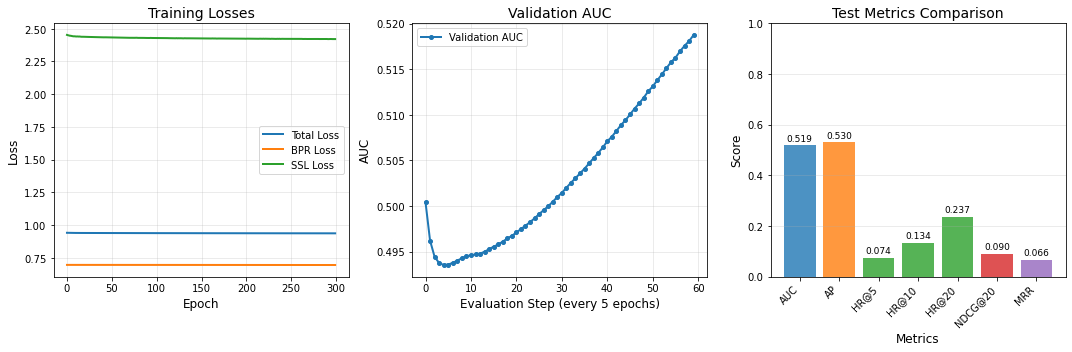

In [66]:
def main_sgl():
    """Main function to run SGL on MovieLens dataset"""
    
    config = {
        'model_type': 'SGL',
        'dataset': 'MovieLens100K',
        'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),

        'hidden_size': 64,
        'num_layers': 2,

        'edge_dropout': 0.2,
        'temperature': 0.2,
        'ssl_weight': 0.1,
        'weight_decay': 1e-5,
        
        'reg_weight': 1e-5,

        'learning_rate': 1e-4,
        'epochs': 300
        
    }
    
            
    print(f"Using device: {config['device']}")
    
    print("\n" + "=" * 60)
    print("STEP 1: Loading MovieLens Dataset")
    print("=" * 60)
    
    data_path = download_and_extract_movielens()
    heterogeneous_data, user_feat_dim, movie_feat_dim = load_movielens_heterogeneous(
        data_path,
        use_features=True,
        use_temporal=True
    )
    
    
    heterogeneous_data = heterogeneous_data.to(config['device'])
    
    print("\n" + "=" * 60)
    print("STEP 2: Training SGL Model")
    print("=" * 60)
    
    start_time = time.time()
    results = train_sgl_with_data(heterogeneous_data, config)
    end_time = time.time()
    
    print("\n" + "=" * 60)
    print("FINAL RESULTS - SGL")
    print("=" * 60)
    print(f"Model: {config['model_type']}")
    print(f"Dataset: {config['dataset']} (Link Prediction)")
    
    print("\n--- LINK PREDICTION METRICS ---")
    print(f"AUC: {results['test_metrics']['AUC']:.4f}")
    print(f"AP: {results['test_metrics']['AP']:.4f}")
    
    
    print("\n--- RECOMMENDATION METRICS ---")
    # Hit Ratio metrics
    print(f"HR@5: {results['rec_metrics']['HR@5']:.4f}")
    print(f"HR@10: {results['rec_metrics']['HR@10']:.4f}")
    print(f"HR@20: {results['rec_metrics']['HR@20']:.4f}")
    
    

    # NDCG metrics
    print(f"NDCG@5: {results['rec_metrics']['NDCG@5']:.4f}")
    print(f"NDCG@10: {results['rec_metrics']['NDCG@10']:.4f}")
    print(f"NDCG@20: {results['rec_metrics']['NDCG@20']:.4f}")
    
    print(f"MRR: {results['rec_metrics']['MRR']:.4f}")
    
    print(f"Time Taken: {end_time - start_time:.2f} seconds")
    
    
    
    # Create visualization
    plt.figure(figsize=(15, 5))
    
    # Subplot 1: Training Losses
    plt.subplot(1, 3, 1)
    losses_array = [l['total_loss'] for l in results['losses']]
    plt.plot(losses_array, label='Total Loss', linewidth=2)
    plt.plot([l['bpr_loss'] for l in results['losses']], label='BPR Loss', linewidth=2)
    plt.plot([l['ssl_loss'] for l in results['losses']], label='SSL Loss', linewidth=2)
    plt.title('Training Losses', fontsize=14)
    plt.xlabel('Epoch', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Subplot 2: Validation AUC over time
    plt.subplot(1, 3, 2)
    plt.plot(results['val_aucs'], marker='o', label='Validation AUC', linewidth=2, markersize=4)
    plt.title('Validation AUC', fontsize=14)
    plt.xlabel('Evaluation Step (every 5 epochs)', fontsize=12)
    plt.ylabel('AUC', fontsize=12)
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    
    # Subplot 3: Test Metrics Comparison
    plt.subplot(1, 3, 3)
    metrics = ['AUC', 'AP', 'HR@5', 'HR@10', 'HR@20','NDCG@20','MRR']
    values = [
        results['test_metrics']['AUC'],
        results['test_metrics']['AP'],
        results['rec_metrics']['HR@5'],
        results['rec_metrics']['HR@10'],
        results['rec_metrics']['HR@20'],
        results['rec_metrics']['NDCG@20'],
        results['rec_metrics']['MRR']
    ]
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#2ca02c', '#2ca02c', '#d62728', '#9467bd']
    bars = plt.bar(metrics, values, color=colors, alpha=0.8)
    plt.title('Test Metrics Comparison', fontsize=14)
    plt.xlabel('Metrics', fontsize=12)
    plt.ylabel('Score', fontsize=12)
    plt.ylim(0, 1)
    plt.xticks(rotation=45, ha='right')
    plt.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on top of bars
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{value:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.show()
    
    return results

if __name__ == '__main__':
    results = main_sgl()